In [32]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score


In [39]:
df = pd.read_csv('mobile-prices.csv', delimiter=";",encoding='latin-1')

In [40]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1.0
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2.0
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2.0
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2.0
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1.0


# Quick data prep

In [41]:
# Check for duplicates
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())

Number of duplicate rows: 0


In [42]:
# If any duplicates
# Remove duplicates
df = df.drop_duplicates()

In [43]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 battery_power       0
blue                0
clock_speed         0
dual_sim            0
fc                  0
four_g              0
int_memory          0
m_dep               0
mobile_wt           0
n_cores             0
pc                  0
px_height           0
px_width            0
ram                 0
sc_h                0
sc_w                0
talk_time           0
three_g             0
touch_screen        0
wifi                0
price_range      1000
dtype: int64


In [44]:
# dealing with missing values under price range

# Solution 1
# Impute missing "price_range" values with the mode
mode_price_range = df['price_range'].mode()[0]
df['price_range'].fillna(mode_price_range, inplace=True)


# Solution 2
# Drop rows with missing "price_range" values
#df = df.dropna(subset=['price_range'])

In [45]:
# Check data types
data_types = df.dtypes
print("Data types:\n", data_types)

Data types:
 battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range      float64
dtype: object


In [46]:
# Convert price_range to a different data type - int
df['price_range'] = df['price_range'].astype(int)

data_types = df.dtypes
print("Data types:\n", data_types)

Data types:
 battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object


# Univariate Analysis

## Battery Power:
What is the distribution of battery power across all mobiles?

Identify the mobiles with the top 5% of battery power.

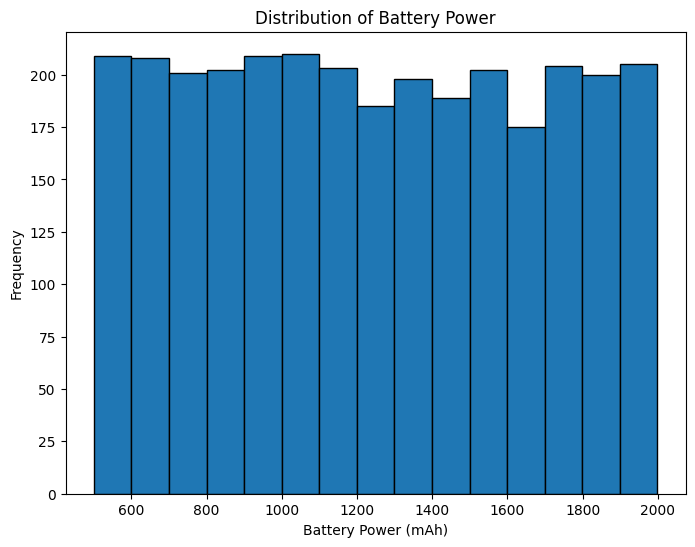

In [10]:
# Plot a histogram to visualize the distribution of battery power
plt.figure(figsize=(8, 6))
plt.hist(df['battery_power'], bins=15, edgecolor='k')
plt.title('Distribution of Battery Power')
plt.xlabel('Battery Power (mAh)')
plt.ylabel('Frequency')
plt.show()

In [11]:
# Calculate the 95th percentile of battery power
battery_power_threshold = df['battery_power'].quantile(0.95)

# Filter the dataset to get mobiles with battery power above the threshold
top_5_percent_mobiles = df[df['battery_power'] > battery_power_threshold]

# Display the top 5% mobiles
print("Mobiles with Top 5% Battery Power:")
top_5_percent_mobiles

Mobiles with Top 5% Battery Power:


,Unnamed: 0,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
7,7,1954,0,0.5,1,0,0,24,0.8,187,...,512,1149,700,16,3,5,1,1,1,0
22,22,1949,0,2.6,1,4,0,47,0.3,199,...,407,822,1433,11,5,20,0,0,1,1
55,55,1936,0,2.1,1,10,1,46,0.6,104,...,667,1036,2552,14,7,13,1,0,0,2
91,91,1977,1,2.0,1,7,1,54,1.0,171,...,1226,1242,1971,18,7,14,1,1,0,2
103,103,1939,1,2.8,1,0,1,55,0.6,199,...,320,520,1047,14,10,18,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,895,1981,0,0.5,0,3,0,38,0.2,103,...,282,1051,1392,5,0,11,0,0,0,0
2898,898,1955,1,1.4,0,1,0,30,0.2,91,...,220,759,2340,9,0,12,1,1,1,0
2965,965,1982,1,2.6,1,7,1,43,0.3,113,...,1409,1679,1791,9,2,8,1,1,0,0
2979,979,1980,0,0.5,1,7,0,15,0.4,141,...,499,1029,1710,11,2,11,1,1,0,0


## RAM:
How is the RAM distributed? Is it skewed towards lower or higher values?

What is the average RAM size across the dataset?

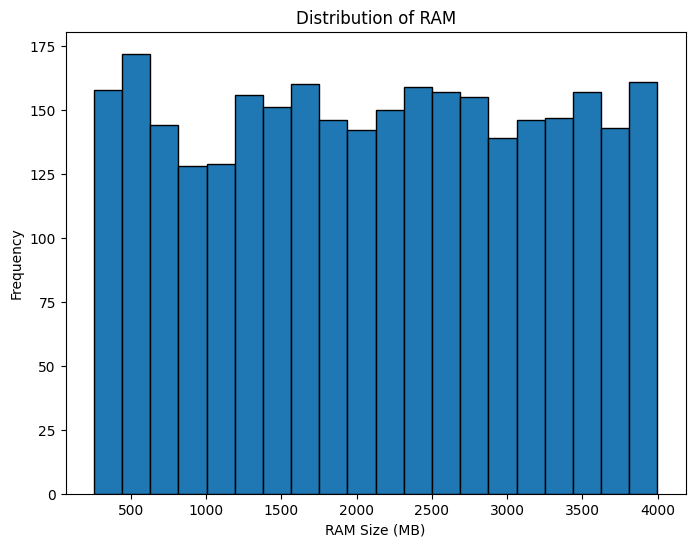

In [12]:
# Plot a histogram to visualize the distribution of RAM
plt.figure(figsize=(8, 6))
plt.hist(df['ram'], bins=20, edgecolor='k')
plt.title('Distribution of RAM')
plt.xlabel('RAM Size (MB)')
plt.ylabel('Frequency')
plt.show()


In [13]:
average_ram_size = df['ram'].mean()
print("Average RAM Size: {:.2f} MB".format(average_ram_size))


Average RAM Size: 2129.14 MB


## Dual SIM:
What proportion of mobiles supports dual SIM?

Is there a particular price range where dual SIM is more common?

In [14]:
# Calculate the proportion of mobiles that support dual SIM
dual_sim_proportion = df['dual_sim'].mean()
print("Proportion of Mobiles with Dual SIM Support: {:.2%}".format(dual_sim_proportion))


Proportion of Mobiles with Dual SIM Support: 51.20%


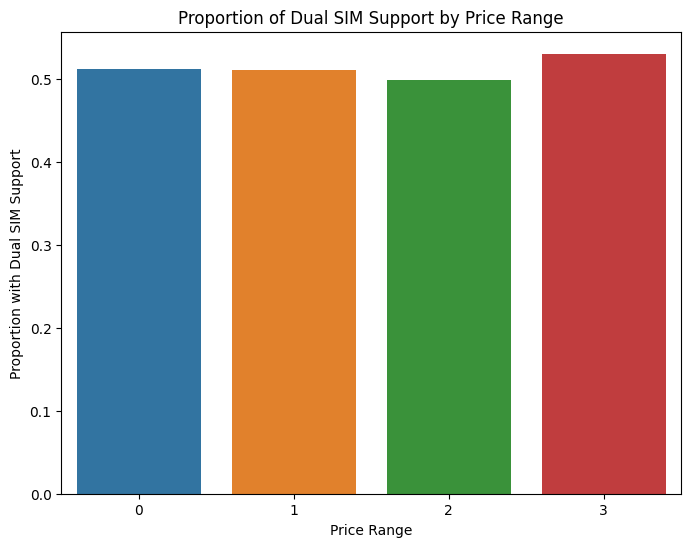

In [15]:
# Group the data by price range and calculate the proportion of dual SIM support in each range
dual_sim_by_price_range = df.groupby('price_range')['dual_sim'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='price_range', y='dual_sim', data=dual_sim_by_price_range)
plt.title('Proportion of Dual SIM Support by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Proportion with Dual SIM Support')
plt.show()

## 4G Support:
What percentage of mobiles have 4G support?

Which price range has the least number of 4G supported mobiles?

In [16]:
# Calculate the percentage of mobiles with 4G support
percentage_4g_support = (df['four_g'].sum() / len(df)) * 100 # or df['four_g'].mean() * 100
print("Percentage of Mobiles with 4G Support: {:.2f}%".format(percentage_4g_support))


Percentage of Mobiles with 4G Support: 51.00%


In [17]:
# Group the data by price range and count the number of 4G-supported mobiles in each range
count_4g_by_price_range = df.groupby('price_range')['four_g'].sum().reset_index()


# Find the price range with the least number of 4G-supported mobiles
min_4g_price_range = count_4g_by_price_range['price_range'].iloc[count_4g_by_price_range['four_g'].idxmin()]

# Display the result
print("Price Range with the Least 4G-Supported Mobiles: {}".format(min_4g_price_range))


Price Range with the Least 4G-Supported Mobiles: 2


In [18]:
count_4g_by_price_range

,price_range,four_g
0,0,746
1,1,262
2,2,247
3,3,275


# Bivariate Analysis

## RAM vs. Battery Power:
Is there any observable relationship between RAM size and battery power?

Which phones (top 5) have both high RAM and high battery power?

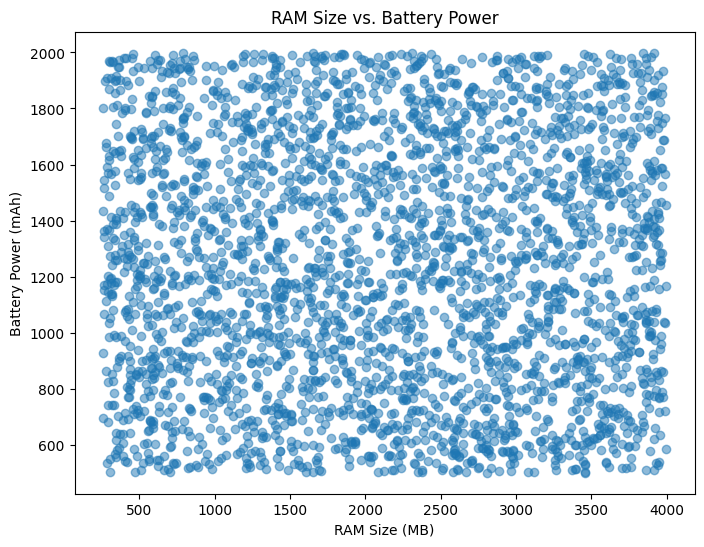

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(df['ram'], df['battery_power'], alpha=0.5)
plt.title('RAM Size vs. Battery Power')
plt.xlabel('RAM Size (MB)')
plt.ylabel('Battery Power (mAh)')
plt.show()

In [20]:
# Sort the DataFrame by RAM size and battery power in descending order
df_sorted = df.sort_values(by=['ram', 'battery_power'], ascending=[False, False])

# Select the top 5 phones with high RAM and high battery power
top_5_high_ram_battery = df_sorted.head(5)

# Display the top 5 phones
print("Top 5 Phones with High RAM and High Battery Power:")
top_5_high_ram_battery


Top 5 Phones with High RAM and High Battery Power:


,Unnamed: 0,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
940,940,1456,0,1.6,1,9,1,39,0.1,80,...,815,1666,3998,6,3,13,1,1,0,3
1816,1816,584,1,1.7,1,1,1,19,0.4,199,...,919,1343,3996,12,9,17,1,1,1,3
69,69,1166,0,1.5,1,0,1,43,0.8,80,...,205,603,3993,7,1,7,1,1,0,3
799,799,1567,0,2.1,1,3,0,22,0.8,153,...,190,1326,3991,15,2,10,1,0,0,3
1684,1684,1035,0,0.5,1,14,1,49,0.3,178,...,574,1171,3991,12,4,19,1,0,0,3


## 4G Support vs. Dual SIM:
Is there a pattern where phones with 4G support more commonly have dual SIM features or vice versa?

In [21]:

# Create a contingency table
contingency_table = pd.crosstab(df['four_g'], df['dual_sim'], margins=True, margins_name="Total")

# Calculate the percentages
percentage_table = (contingency_table / contingency_table.loc["Total", "Total"]) * 100

# Display the contingency table
print("Contingency Table (4G Support vs. Dual SIM):")
contingency_table


Contingency Table (4G Support vs. Dual SIM):


dual_sim,0,1,Total
four_g,,,
0,725,745,1470
1,739,791,1530
Total,1464,1536,3000


In [22]:
# Display the percentage table
print("\nPercentage Table (in %):")
percentage_table


Percentage Table (in %):


dual_sim,0,1,Total
four_g,,,
0,24.166667,24.833333,49.0
1,24.633333,26.366667,51.0
Total,48.800000,51.200000,100.0


In [23]:
from scipy.stats import chi2_contingency
# Perform the chi-squared test
chi2, p, _, _ = chi2_contingency(contingency_table)

# Display the chi-squared statistic and p-value
print("Chi-Squared Statistic:", chi2)
print("P-value:", p)

Chi-Squared Statistic: 0.3116085915240402
P-value: 0.9890525303420777


## Battery Power vs. Price Range:
How does the battery power distribution vary across different price ranges?

Is there a noticeable difference in average battery power between the lowest and highest price range?

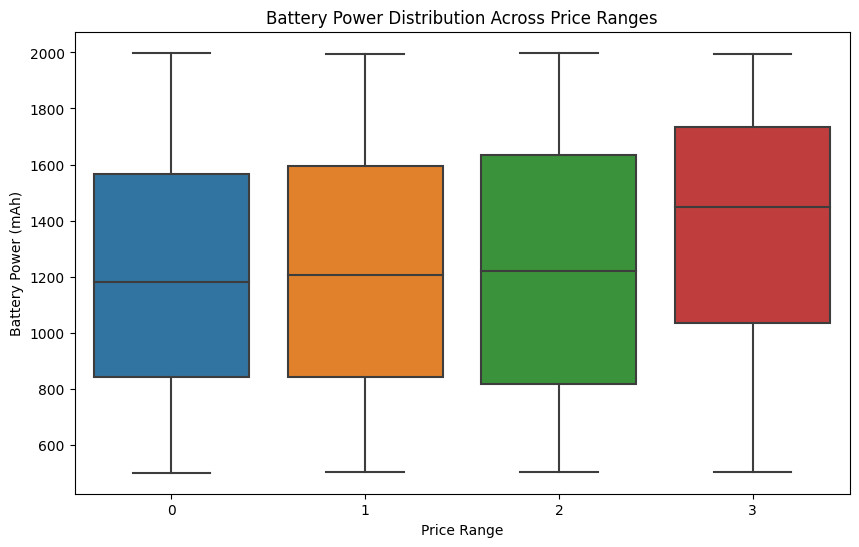

In [24]:
# Create a box plot to visualize battery power distribution across price ranges
plt.figure(figsize=(10, 6))
sns.boxplot(x='price_range', y='battery_power', data=df)
plt.title('Battery Power Distribution Across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Battery Power (mAh)')
plt.show()

In [25]:
# Calculate the average battery power by price range
average_battery_power_by_range = df.groupby('price_range')['battery_power'].mean()

# Display the average battery power for each price range
print("Average Battery Power by Price Range:")
print(average_battery_power_by_range)


Average Battery Power by Price Range:
price_range
0    1204.640667
1    1228.868000
2    1228.320000
3    1379.984000
Name: battery_power, dtype: float64


In [26]:
from scipy.stats import ttest_ind

# Extract battery power values for the lowest and highest price ranges
lowest_price_battery_power = df[df['price_range'] == 0]['battery_power']
highest_price_battery_power = df[df['price_range'] == 3]['battery_power']

# Perform a t-test
t_stat, p_value = ttest_ind(lowest_price_battery_power, highest_price_battery_power)

# Display the t-statistic and p-value
print("T-Statistic:", t_stat)
print("P-Value:", p_value)


T-Statistic: -7.968868058556141
P-Value: 2.665826651310252e-15


## RAM vs. Price Range:
How does RAM distribution vary across price ranges?

Is there a clear distinction in RAM size when moving from a lower to a higher price range?

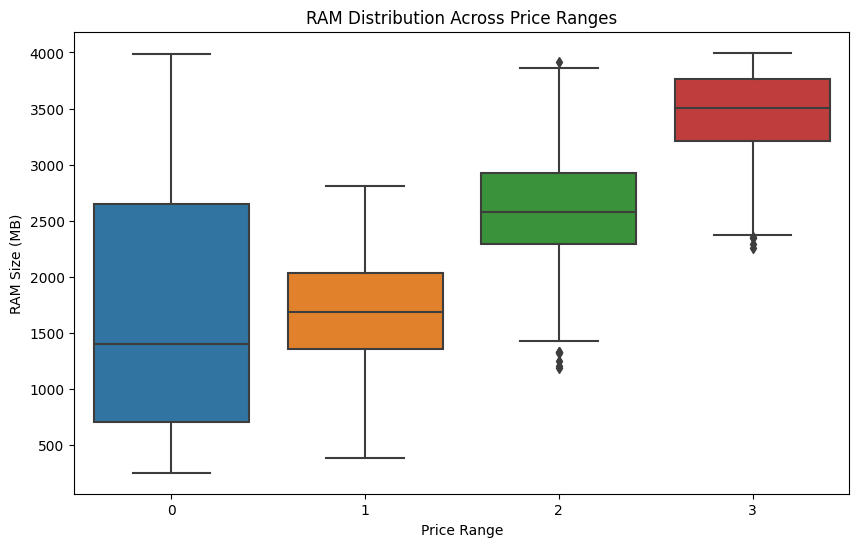

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='price_range', y='ram', data=df)
plt.title('RAM Distribution Across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('RAM Size (MB)')
plt.show()

In [28]:
# Calculate the average RAM size by price range
average_ram_by_range = df.groupby('price_range')['ram'].mean()

# Display the average RAM size for each price range
print("Average RAM Size by Price Range:")
print(average_ram_by_range)


Average RAM Size by Price Range:
price_range
0    1687.770
1    1679.490
2    2582.816
3    3449.232
Name: ram, dtype: float64


In [29]:
from scipy.stats import f_oneway

# Extract RAM sizes for each price range
ram_by_price_range = [df[df['price_range'] == i]['ram'] for i in range(4)]

# Perform ANOVA test
f_statistic, p_value = f_oneway(*ram_by_price_range)

# Display the F-statistic and p-value
print("F-Statistic:", f_statistic)
print("P-Value:", p_value)


F-Statistic: 630.092169946451
P-Value: 1.602689e-317


# Prediction of Price Range:

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Split the dataset into features (X) and target variable (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

# Split the data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = rf_classifier.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
classification_report_result = classification_report(y_test, y_pred, target_names=["Low Cost", "Medium Cost", "High Cost", "Very High Cost"])
confusion = confusion_matrix(y_test, y_pred)

# Print the evaluation results
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report_result)
print("\nConfusion Matrix:")
print(confusion)


Accuracy: 0.6344444444444445

Classification Report:
                precision    recall  f1-score   support

      Low Cost       0.64      0.80      0.71       459
   Medium Cost       0.61      0.24      0.35       148
     High Cost       0.60      0.41      0.49       150
Very High Cost       0.66      0.76      0.70       143

      accuracy                           0.63       900
     macro avg       0.63      0.55      0.56       900
  weighted avg       0.63      0.63      0.61       900


Confusion Matrix:
[[365  18  26  50]
 [105  36   7   0]
 [ 77   5  62   6]
 [ 26   0   9 108]]


In [48]:
# Get feature importances
feature_importances = rf_classifier.feature_importances_

# Create a DataFrame to display feature importances
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print("Feature Importances:")
print(importance_df)

Feature Importances:
          Feature  Importance
13            ram    0.290581
0   battery_power    0.078143
11      px_height    0.070984
12       px_width    0.070011
8       mobile_wt    0.055408
6      int_memory    0.053532
16      talk_time    0.045896
2     clock_speed    0.043640
10             pc    0.043090
15           sc_w    0.042580
14           sc_h    0.040638
4              fc    0.036313
7           m_dep    0.035628
9         n_cores    0.033870
1            blue    0.010587
3        dual_sim    0.010253
5          four_g    0.010076
19           wifi    0.010020
18   touch_screen    0.009668
17        three_g    0.009082
